In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import data


In [16]:
df = pd.read_csv(r"D:\pro\mlpro\notebook\data\stud.csv")

Show Top 5 Records


In [17]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.shape

In [19]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [23]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [26]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [25]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [27]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [28]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [29]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [30]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


4. Exploring Data ( Visualization )


4.1 Visualize average score distribution to make some conclusion.

Histogram

Kernel Distribution Function (KDE)

4.1.1 Histogram & KDE

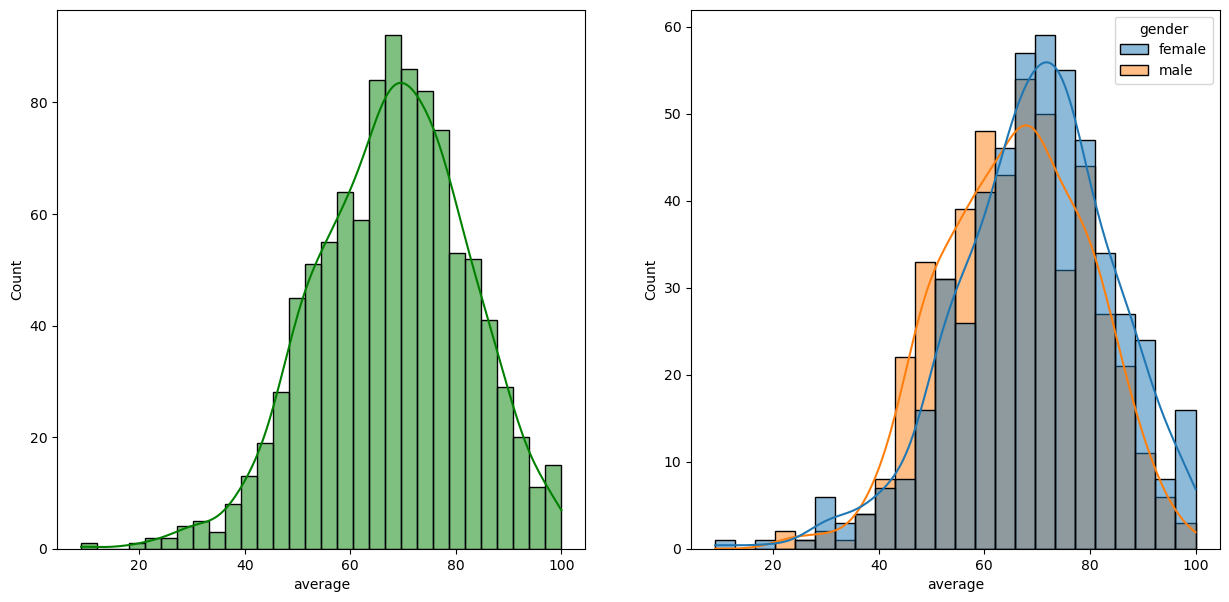

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

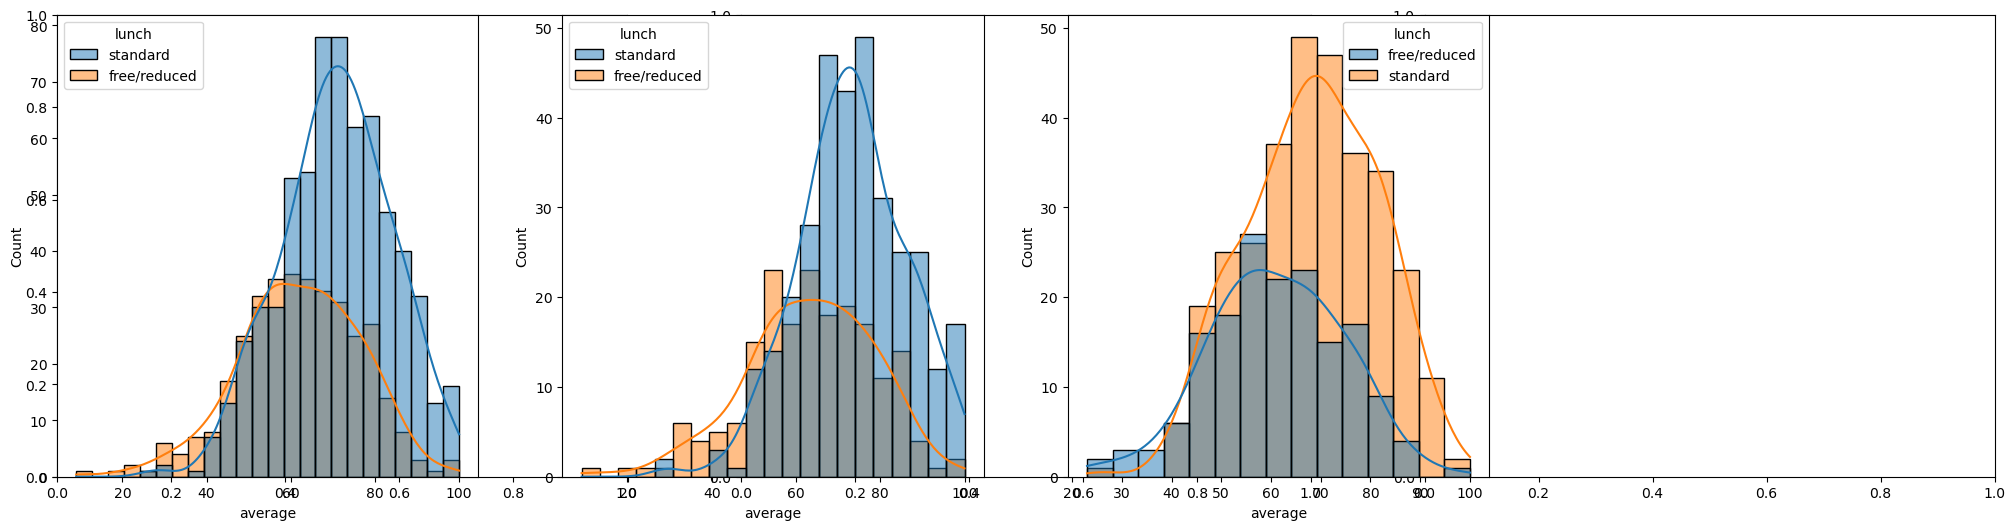

In [34]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

Insights

Standard lunch helps perform well in exams.

Standard lunch helps perform well in exams be it a male or a female.

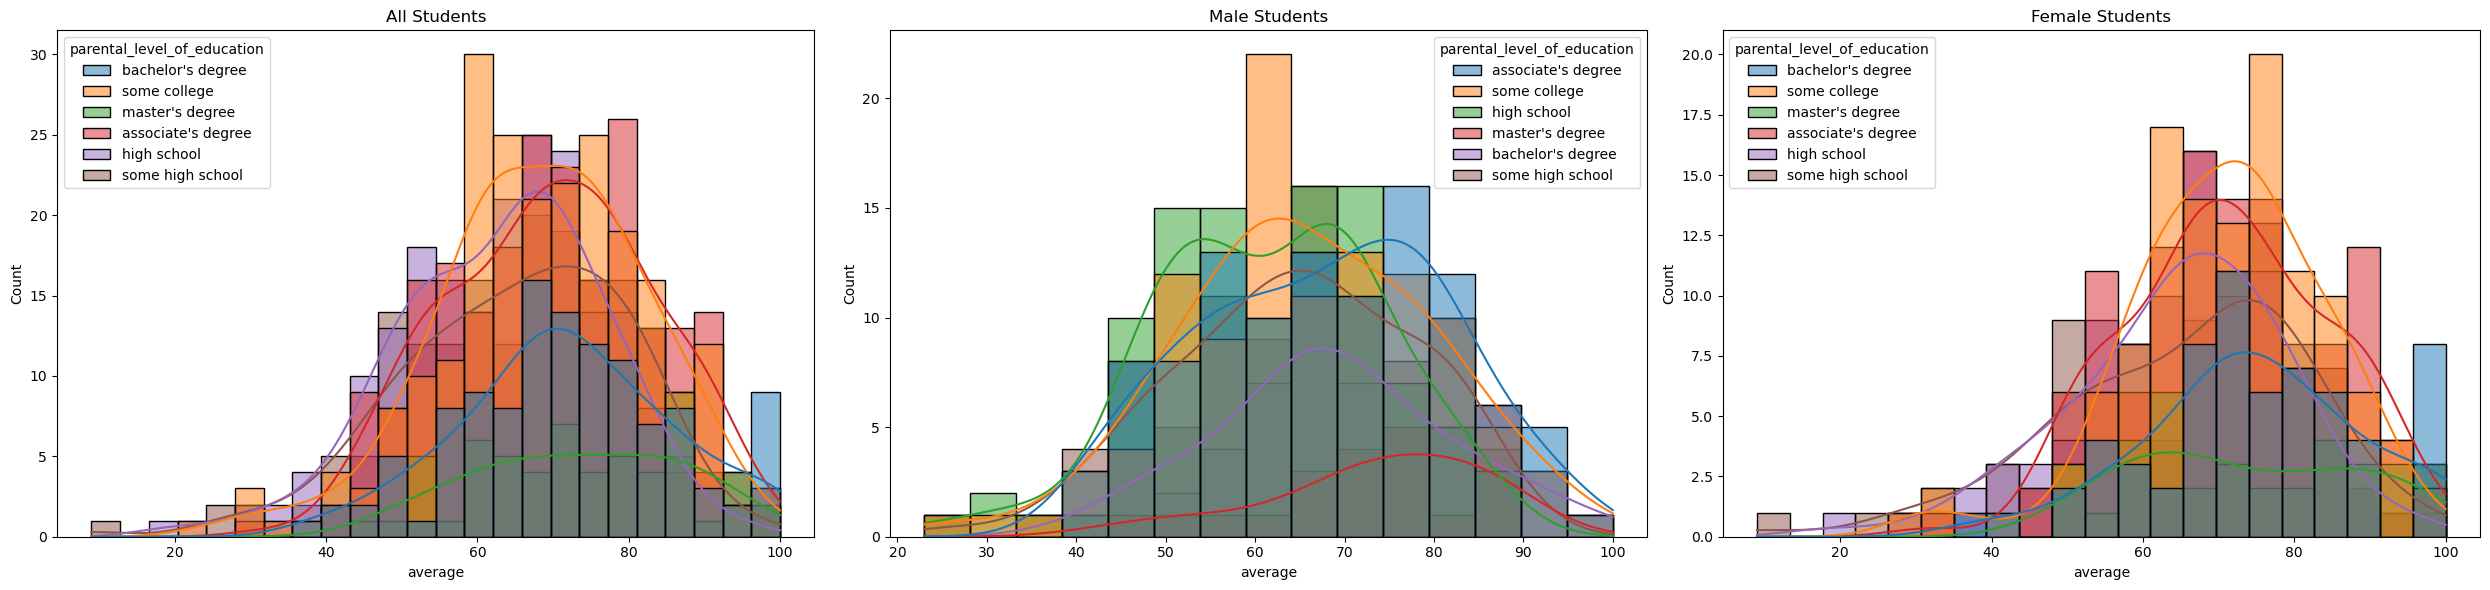

In [39]:


fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education', ax=axes[0])
axes[0].set_title("All Students")

sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='parental_level_of_education', ax=axes[1])
axes[1].set_title("Male Students")

sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='parental_level_of_education', ax=axes[2])
axes[2].set_title("Female Students")

plt.tight_layout()
plt.show()



Insights

1.In general parent's education don't help student perform well in exam.

2.2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam

3.3rd plot we can see there is no effect of parent's education on female students.

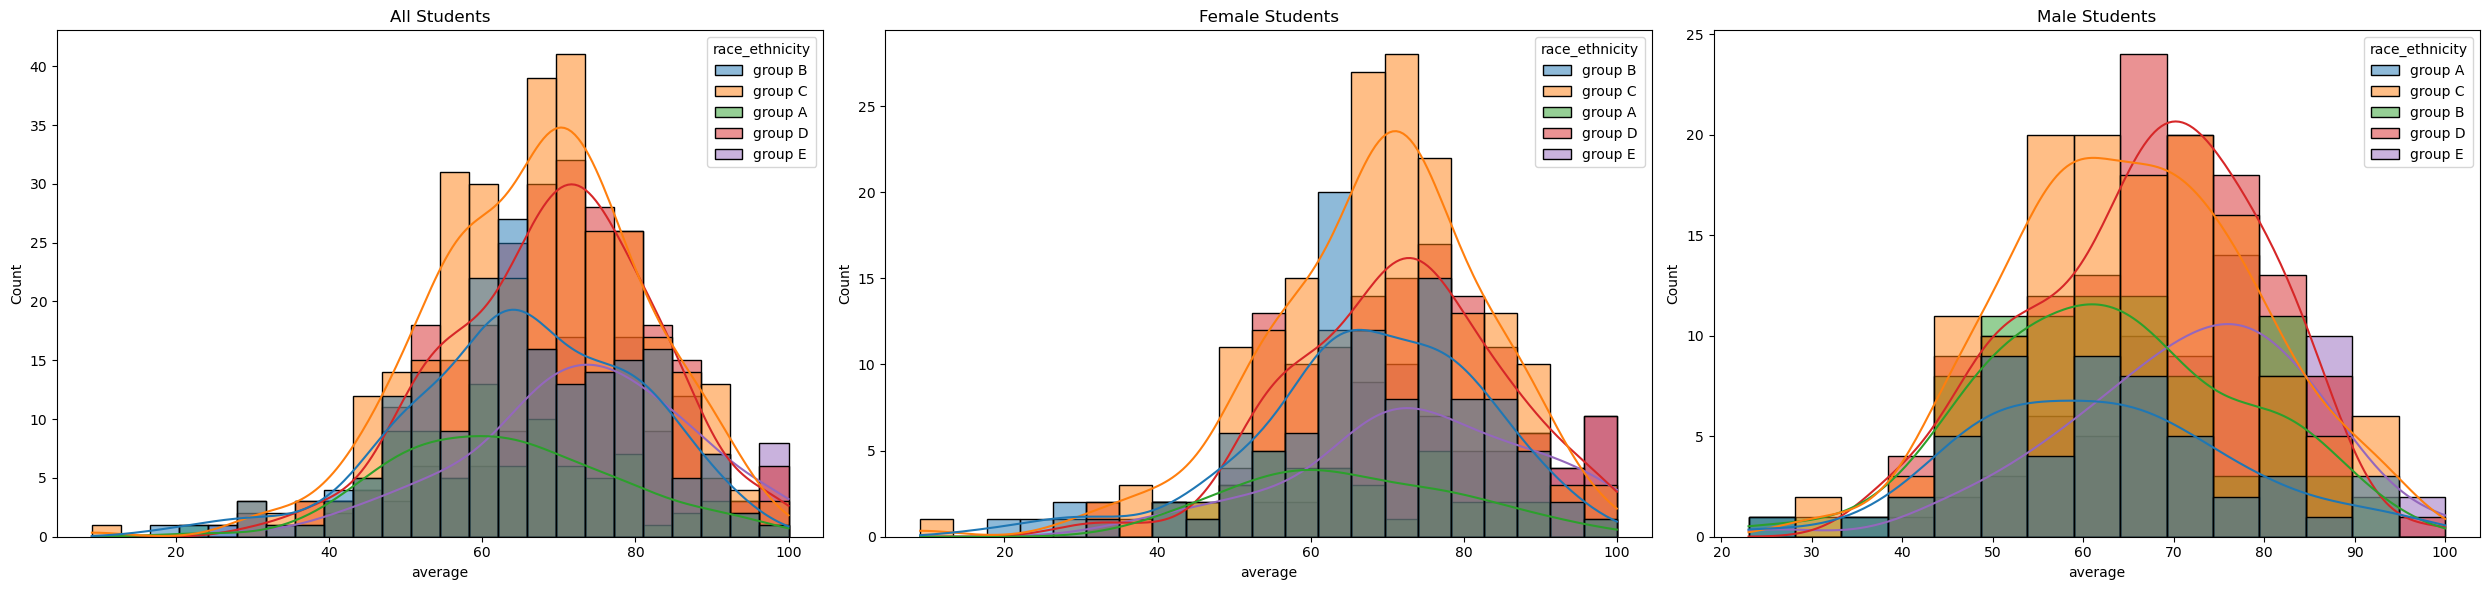

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity', ax=axes[0])
axes[0].set_title("All Students")

sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='race_ethnicity', ax=axes[1])
axes[1].set_title("Female Students")

sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='race_ethnicity', ax=axes[2])
axes[2].set_title("Male Students")

plt.tight_layout()
plt.show()



4.2 Maximumum score of students in all three subjects

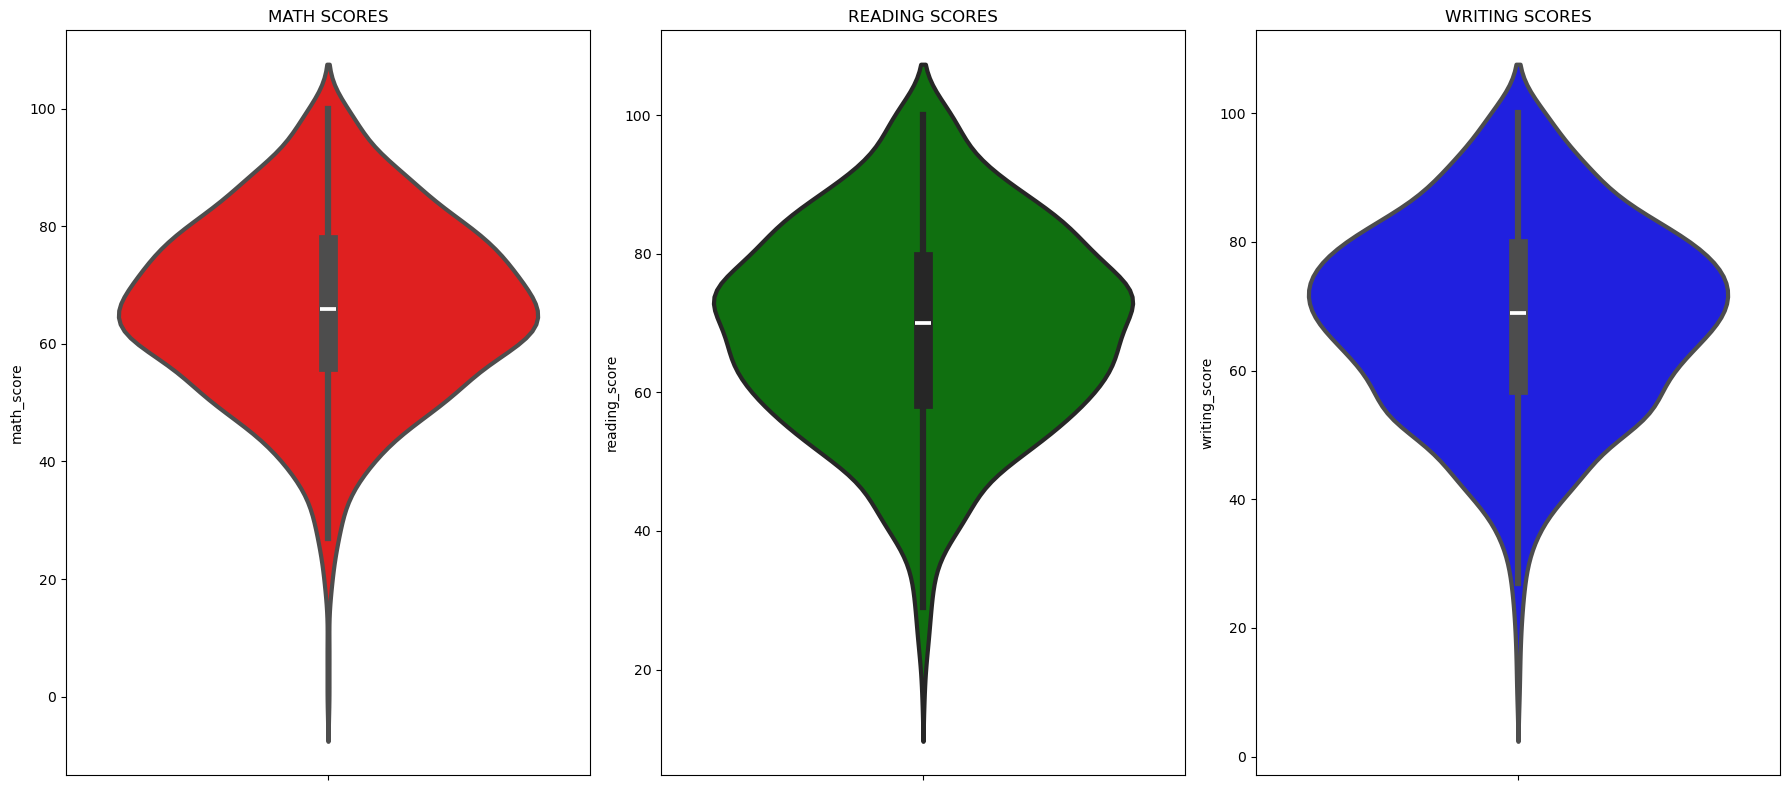

In [45]:

plt.figure(figsize=(18, 8))

# Math scores
plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)

# Reading scores
plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

# Writing scores
plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.tight_layout()
plt.show()



Insights

* From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80


4.3 Multivariate analysis using pieplot

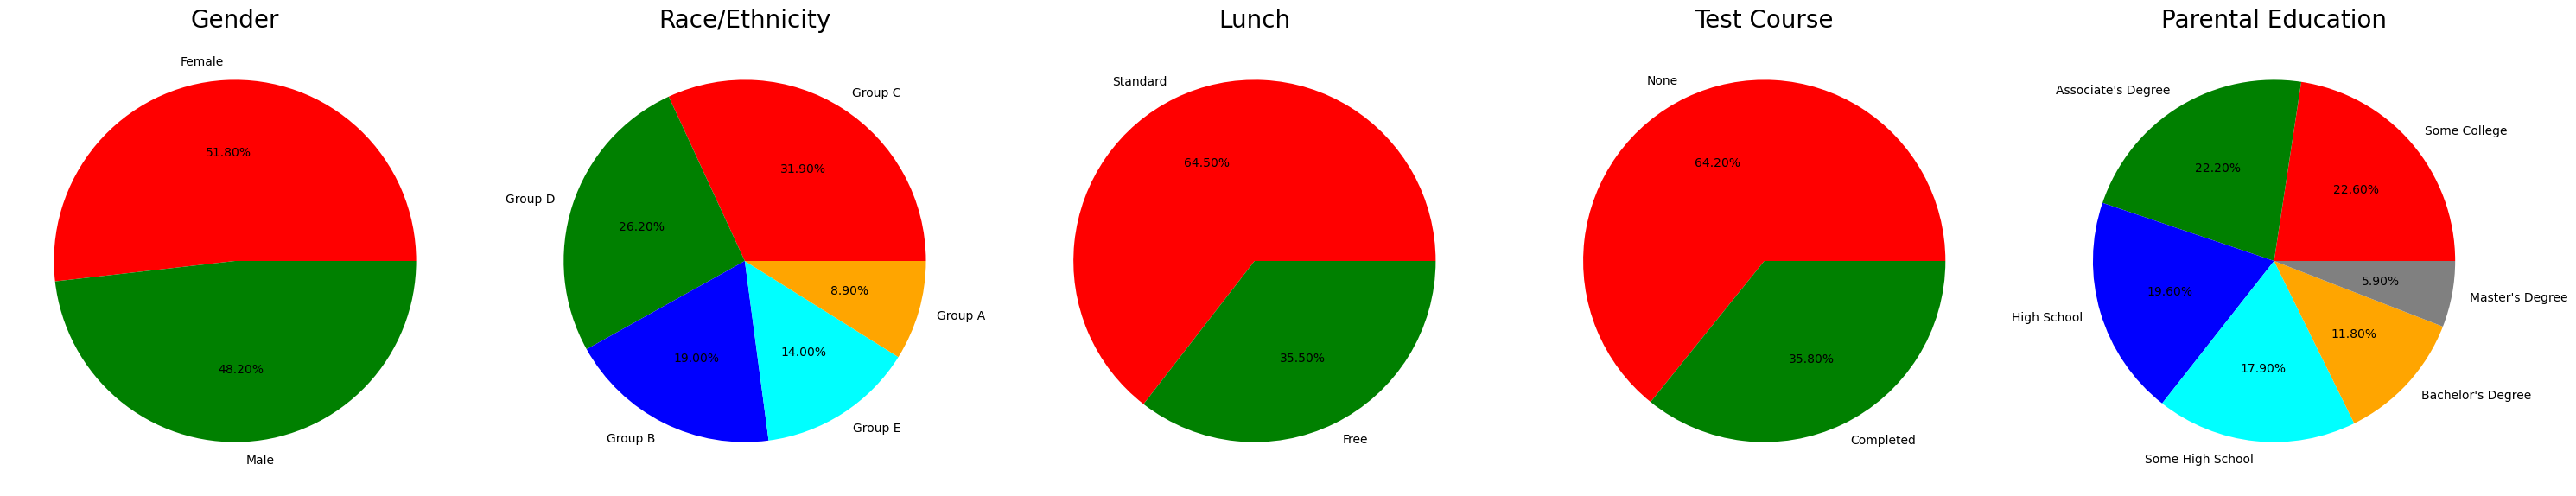

In [47]:
plt.rcParams['figure.figsize'] = (30, 12)

# Gender
plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = ['Female', 'Male']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')

# Race/Ethnicity
plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = ['Group C', 'Group D','Group B','Group E','Group A']
colors = ['red', 'green', 'blue', 'cyan','orange']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')

# Lunch
plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = ['Standard', 'Free']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')

# Test Preparation Course
plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = ['None', 'Completed']
colors = ['red','green']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')

# Parental Education
plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = ['Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"]
colors = ['red', 'green', 'blue', 'cyan','orange','grey']
plt.pie(size, colors=colors, labels=labels, autopct='%1.2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.show()



Insights 

* Number of Male and Female students is almost equal 

* Number students are greatest in Group C

* Number of students who have standard lunch are greater

* Number of students who have not enrolled in any test preparation course is greater

* Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"


4.4 Feature Wise Visualization3


4.4.1 GENDER COLUMN

* How is distribution of Gender ?
* Is gender has any impact on student's performance ?


UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

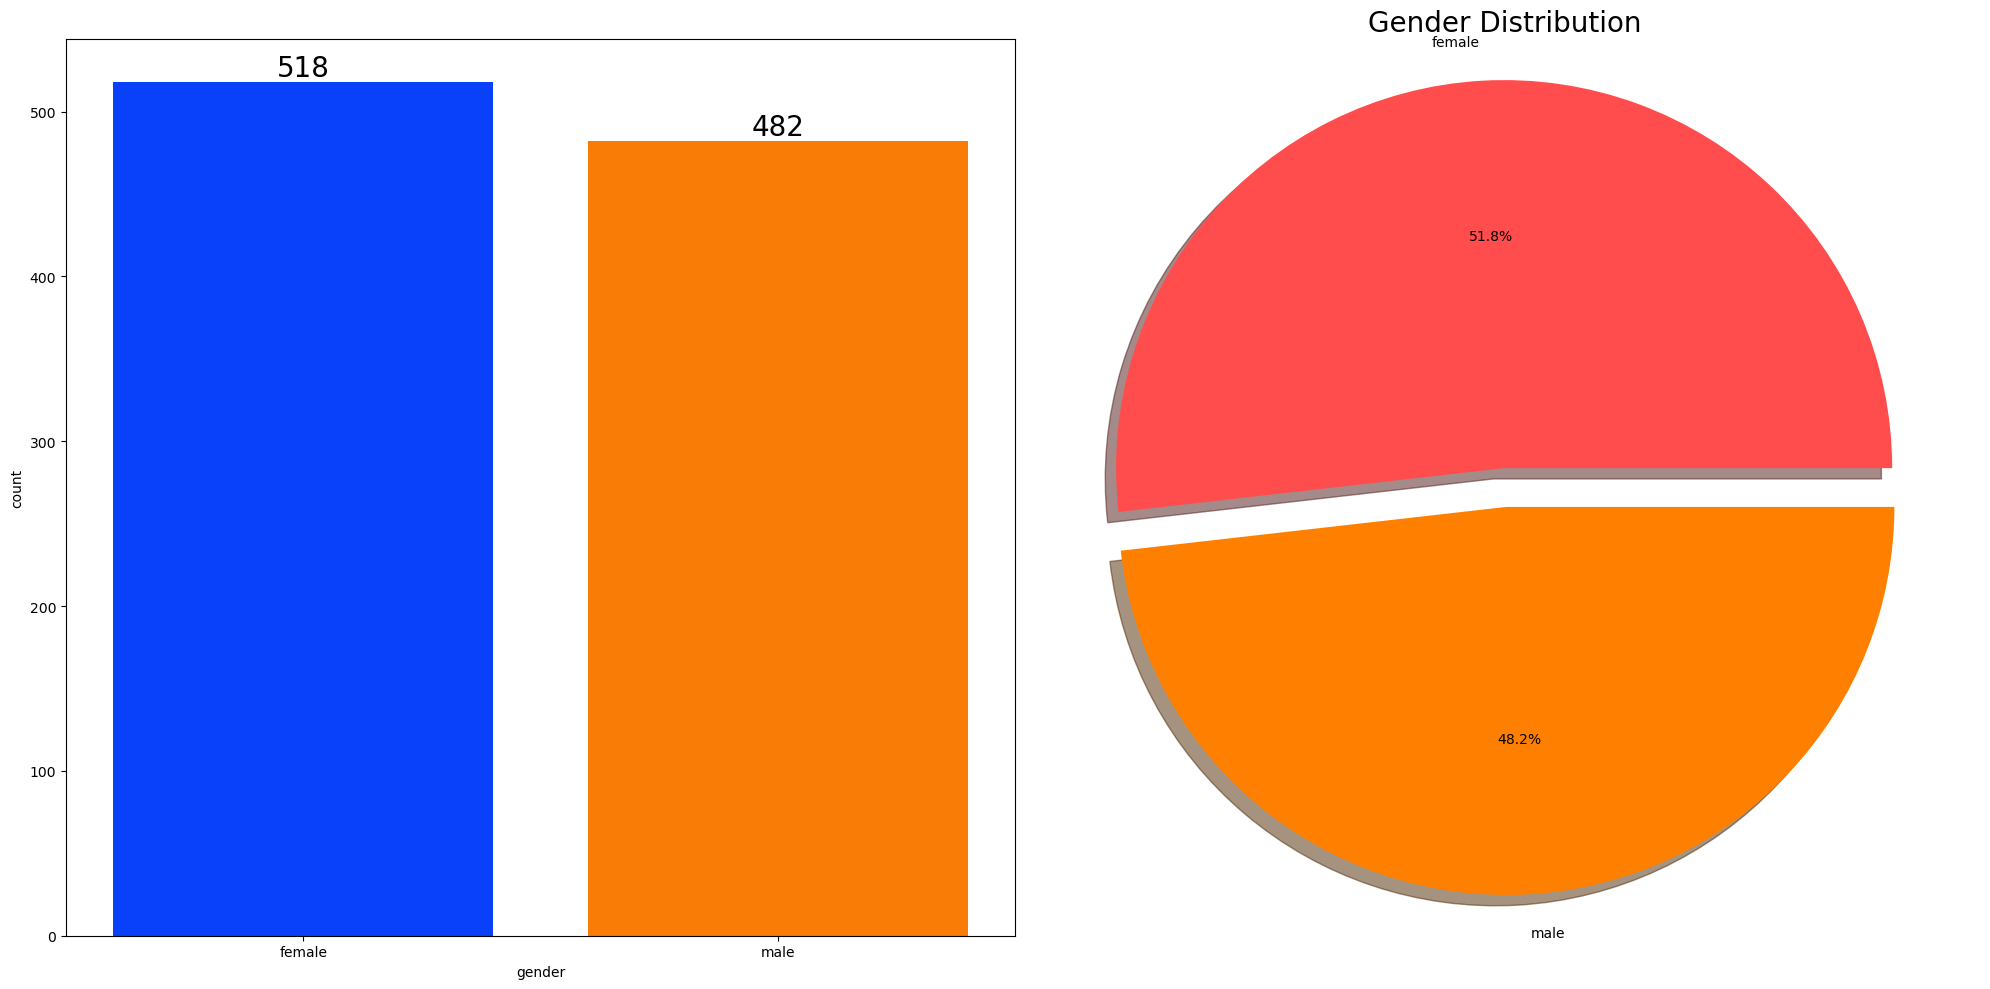

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Countplot
sns.countplot(x='gender', data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie chart
sizes = df['gender'].value_counts()
labels = sizes.index.tolist()   # ensures correct order
colors = ['#ff4d4d', '#ff8000']
explode = [0, 0.1]  # highlight one slice

plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%',
        shadow=True, colors=colors)
plt.title('Gender Distribution', fontsize=20)
plt.axis('equal')  # keeps pie circular

plt.tight_layout()
plt.show()



Insights

* Gender has balanced data with female students are 518 (48%) and male students are 482 (52%)


BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [59]:
# Option 1: Let Pandas handle it automatically
gender_group = df.groupby('gender').mean(numeric_only=True)



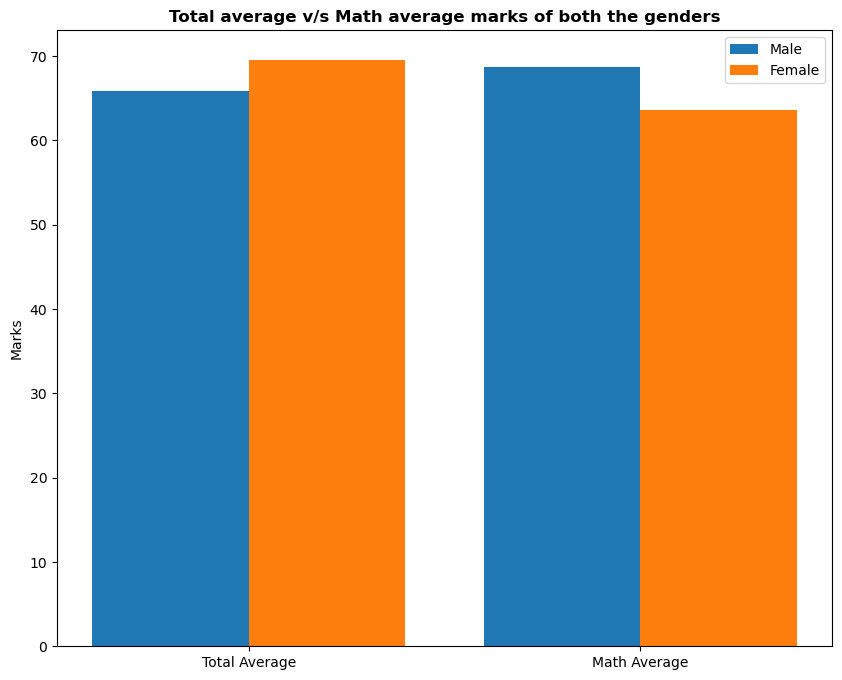

In [62]:
import numpy as np
import matplotlib.pyplot as plt

gender_group = df.groupby('gender').mean(numeric_only=True)

plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']   # <-- underscore
]
male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']     # <-- underscore
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()


Insights


* On an average females have a better overall score than men.
* whereas males have scored higher in Maths.


4.4.2 RACE/EHNICITY COLUMN

* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?


UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

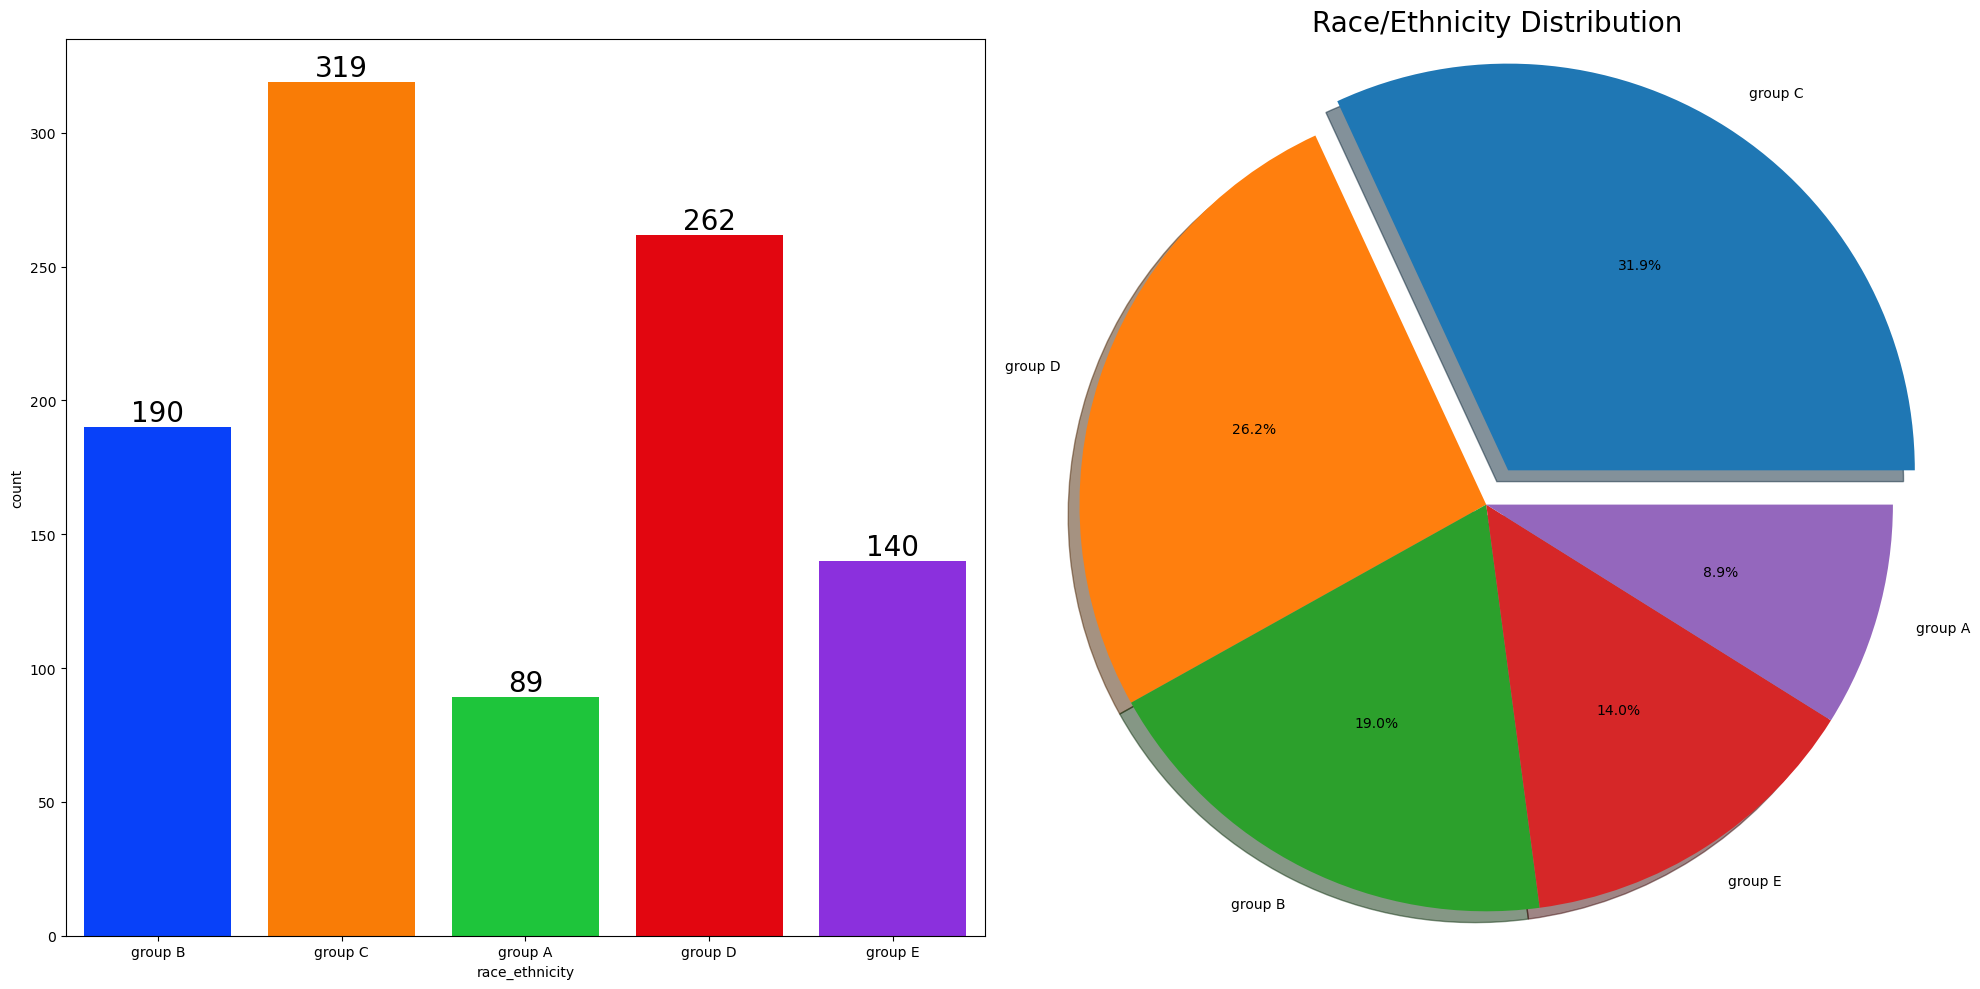

In [63]:


f, ax = plt.subplots(1, 2, figsize=(20, 10))

# Countplot
sns.countplot(x='race_ethnicity', data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie chart
sizes = df['race_ethnicity'].value_counts()
labels = sizes.index.tolist()   # ensures labels match actual groups
explode = [0.1] + [0]*(len(labels)-1)  # explode only the first slice

plt.subplot(1, 2, 2)
plt.pie(sizes, labels=labels, explode=explode, autopct='%1.1f%%', shadow=True)
plt.title('Race/Ethnicity Distribution', fontsize=20)
plt.axis('equal')  # keeps pie circular

plt.tight_layout()
plt.show()


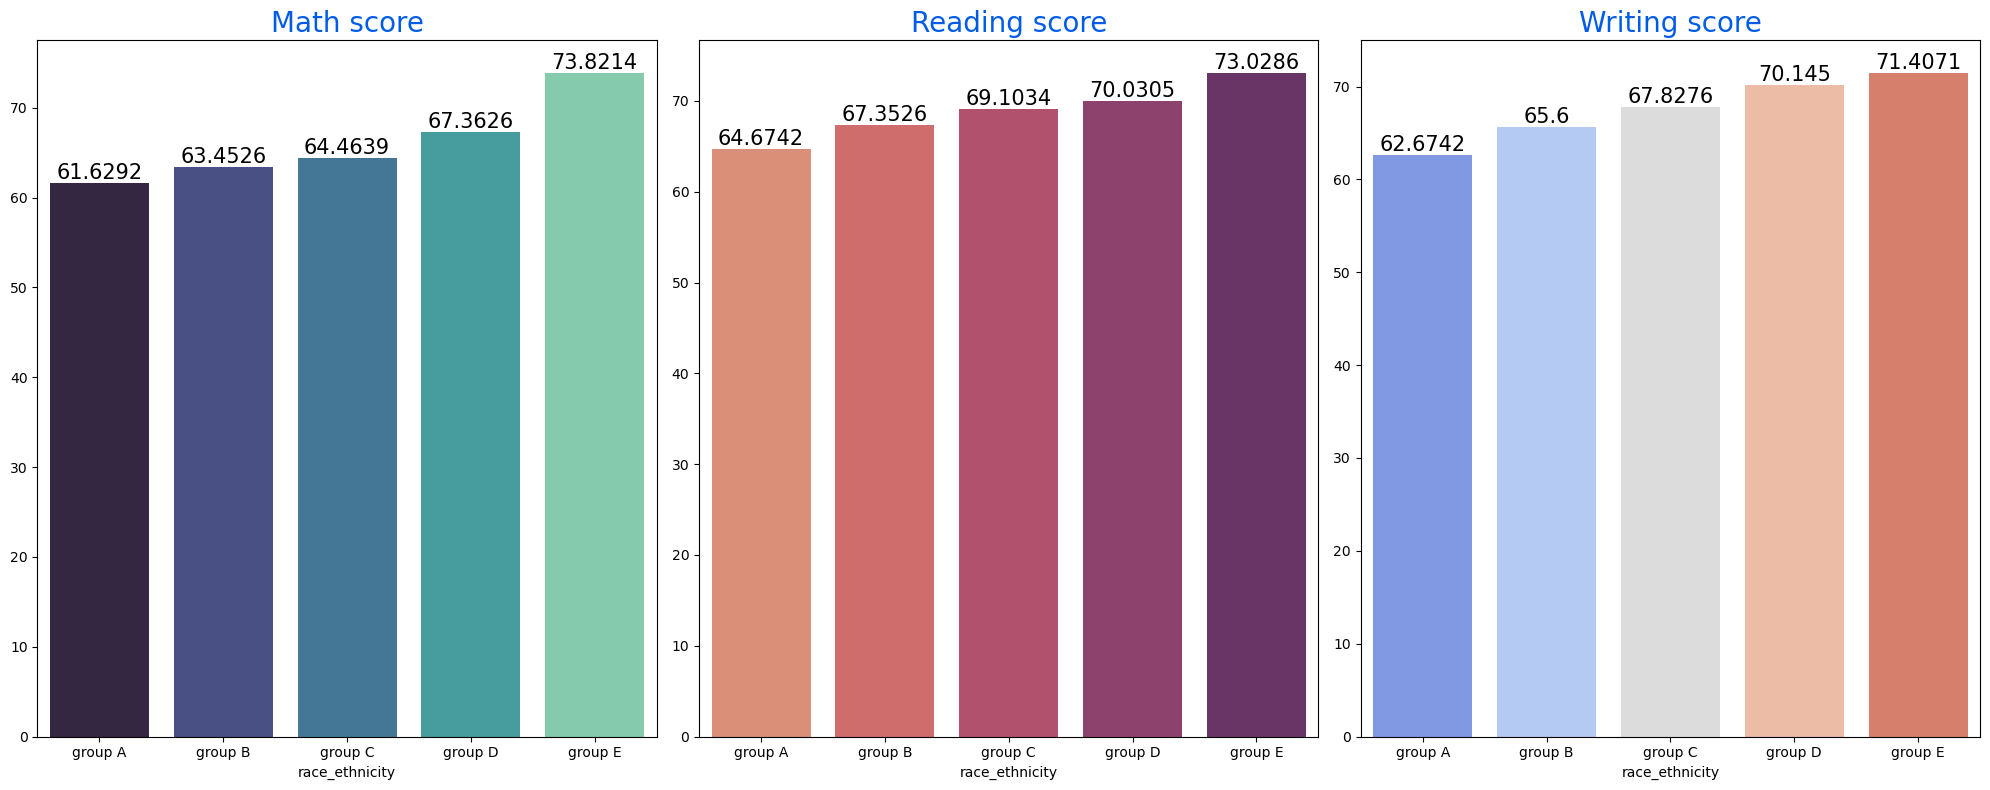

In [64]:
Group_data2 = df.groupby('race_ethnicity')   # <-- match actual column name

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Math
sns.barplot(
    x=Group_data2['math_score'].mean().index,
    y=Group_data2['math_score'].mean().values,
    palette='mako',
    ax=ax[0]
)
ax[0].set_title('Math score', color='#005ce6', size=20)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)

# Reading
sns.barplot(
    x=Group_data2['reading_score'].mean().index,
    y=Group_data2['reading_score'].mean().values,
    palette='flare',
    ax=ax[1]
)
ax[1].set_title('Reading score', color='#005ce6', size=20)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)

# Writing
sns.barplot(
    x=Group_data2['writing_score'].mean().index,
    y=Group_data2['writing_score'].mean().values,
    palette='coolwarm',
    ax=ax[2]
)
ax[2].set_title('Writing score', color='#005ce6', size=20)
for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()



Insights

* Group E students have scored the highest marks.
* Group A students have scored the lowest marks.
* Students from a lower Socioeconomic status have a lower avg in all course subjects

4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN

* What is educational background of student's parent ?
* Is parental education has any impact on student's performance ?


UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

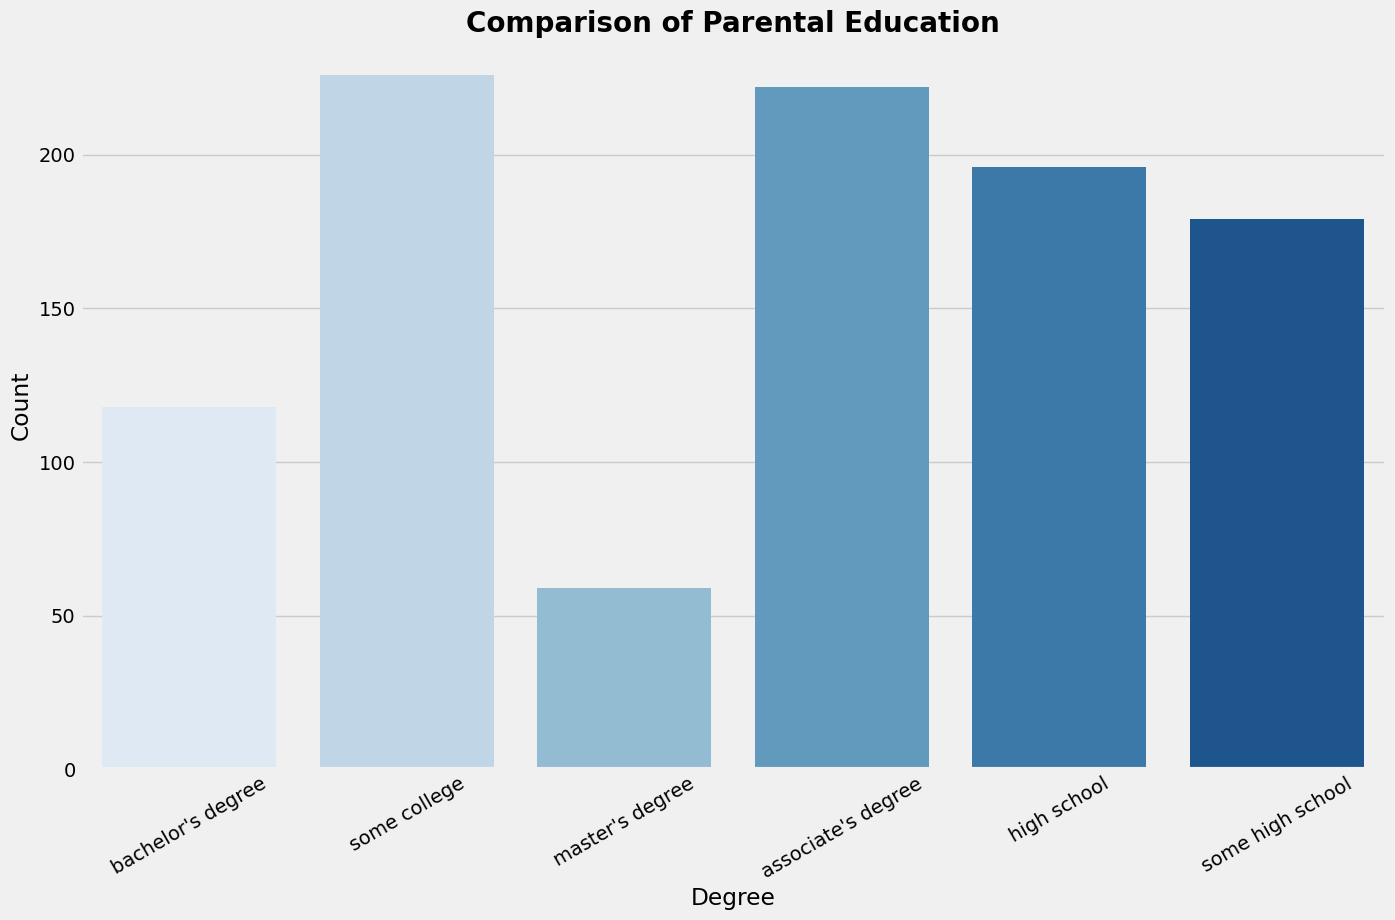

In [65]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')

sns.countplot(x='parental_level_of_education', data=df, palette='Blues')
plt.title('Comparison of Parental Education', fontweight='bold', fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=30)  # rotate labels for readability
plt.show()


Insights

* Largest number of parents are from some college.


BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

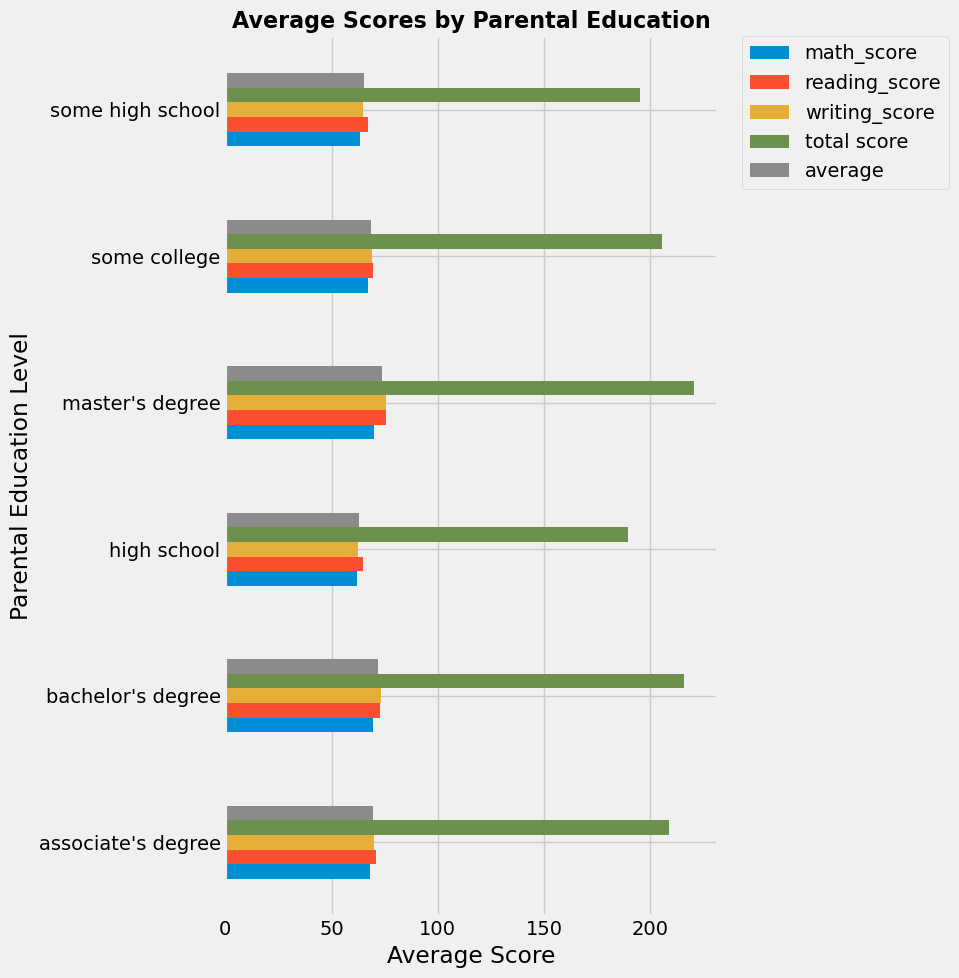

In [66]:

# Group by parental education and take mean of numeric columns
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(
    kind='barh', figsize=(10, 10)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("Average Scores by Parental Education", fontsize=16, fontweight='bold')
plt.xlabel("Average Score")
plt.ylabel("Parental Education Level")
plt.tight_layout()
plt.show()


Insights

The score of student whose parents possess master and bachelor level education are higher than others.


4.4.4 LUNCH COLUMN

* Which type of lunch is most common amoung students ?
* What is the effect of lunch type on test results?


UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

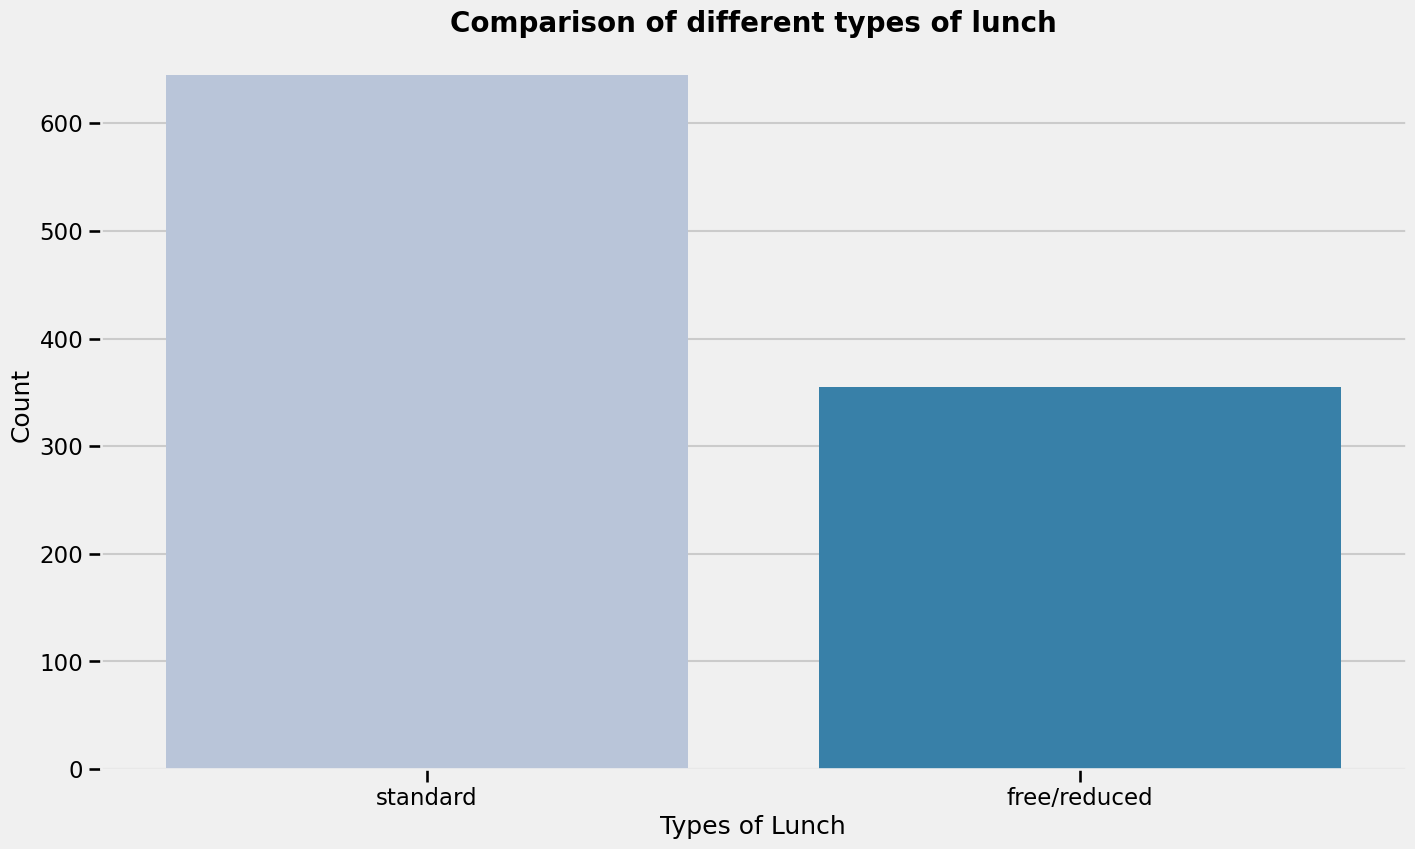

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (15, 9)
sns.set_context("talk")   # ✅ presentation style

sns.countplot(x='lunch', data=df, palette='PuBu')
plt.title('Comparison of different types of lunch', fontweight='bold', fontsize=20)
plt.xlabel('Types of Lunch')
plt.ylabel('Count')
plt.show()



Insights
* Students being served Standard lunch was more than free lunch


BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )

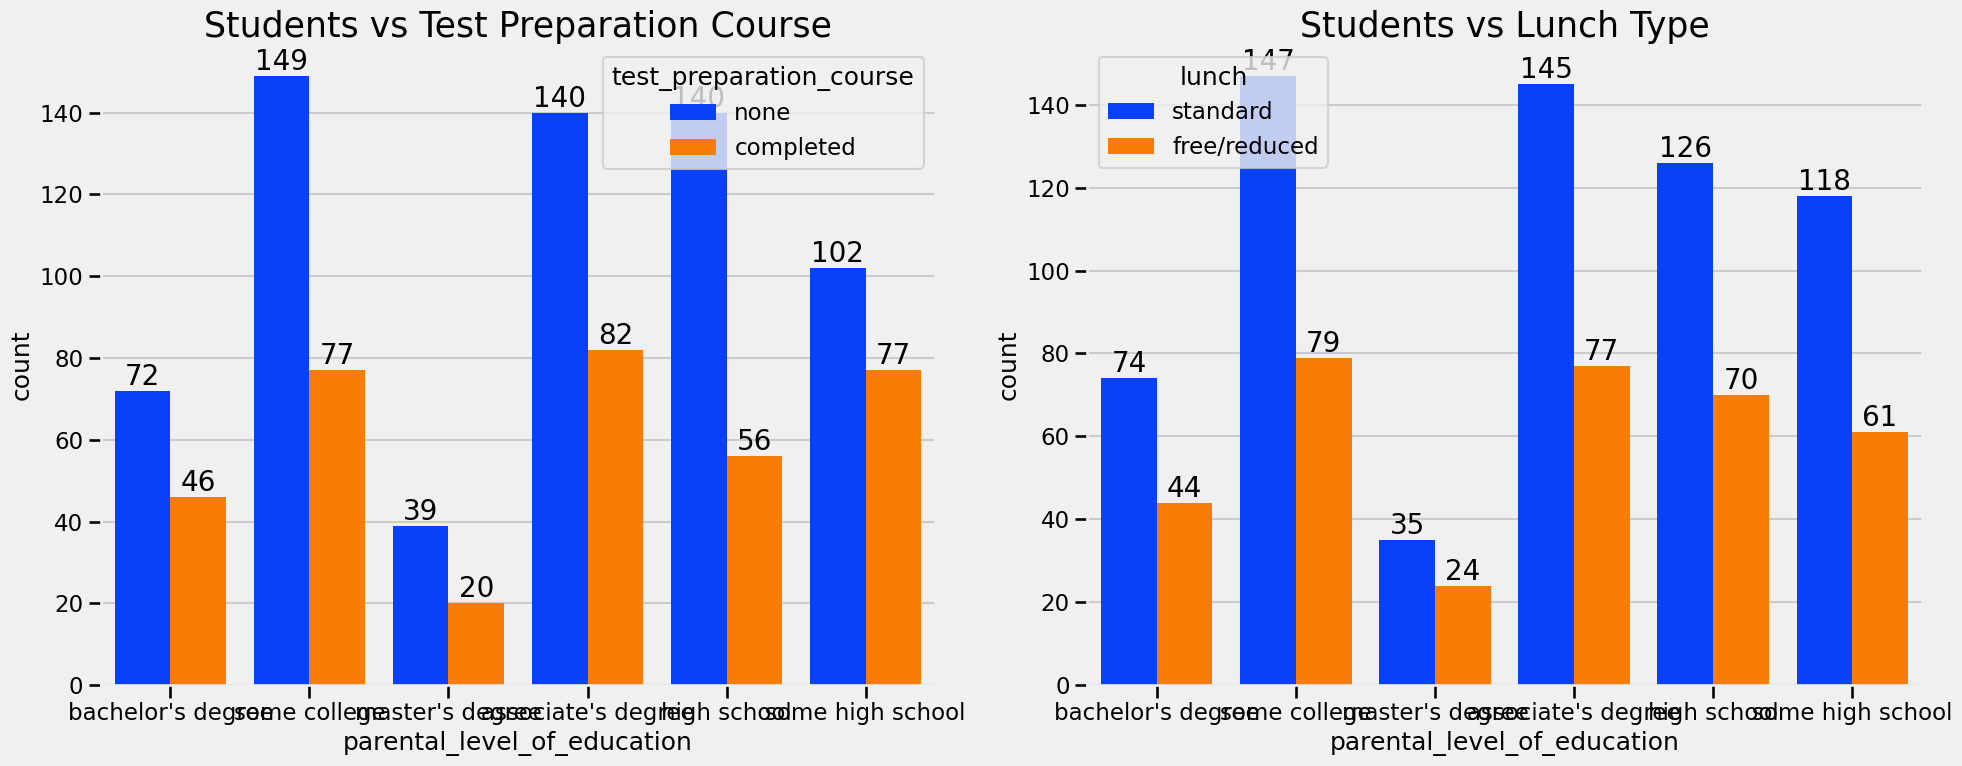

In [ ]:

f, ax = plt.subplots(1, 2, figsize=(20, 8))

# Parental education vs test prep
sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='test_preparation_course',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs Test Preparation Course', color='black', size=25)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Parental education vs lunch
sns.countplot(
    x='parental_level_of_education',
    data=df,
    palette='bright',
    hue='lunch',
    saturation=0.95,
    ax=ax[1]
)
ax[1].set_title('Students vs Lunch Type', color='black', size=25)
for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=20)

plt.tight_layout()
plt.show()



Insights

* Students who get Standard Lunch tend to perform better than students who got free/reduced lunch


4.4.5 TEST PREPARATION COURSE COLUMN

* Which type of lunch is most common amoung students ?
* Is Test prepration course has any impact on student's performance 



 BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

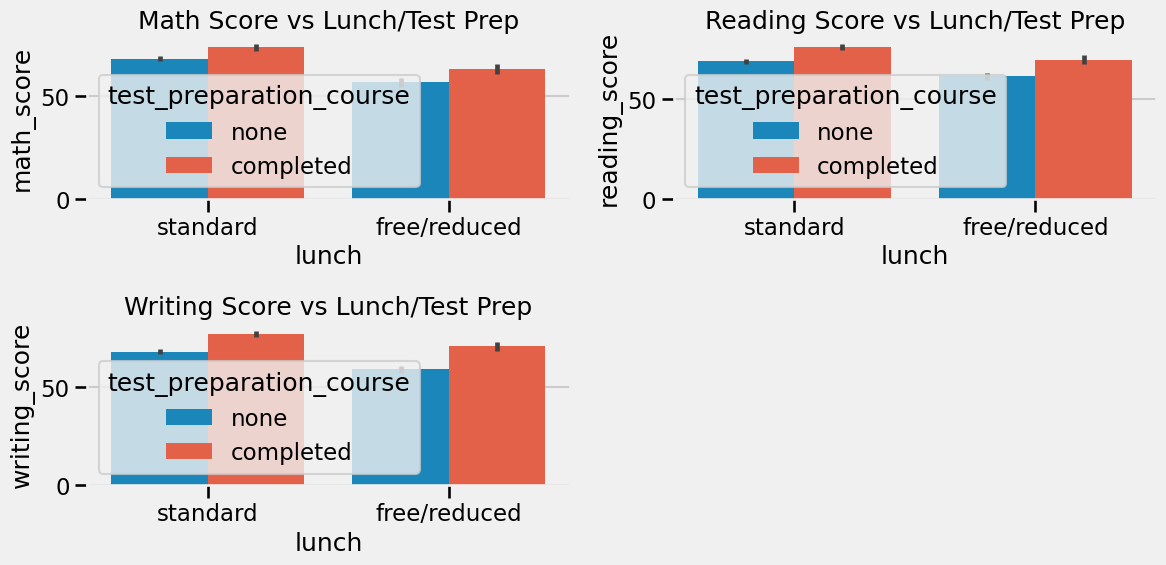

In [72]:

plt.figure(figsize=(12,6))

# Math score vs lunch + test prep
plt.subplot(2,2,1)
sns.barplot(x='lunch', y='math_score', hue='test_preparation_course', data=df)
plt.title("Math Score vs Lunch/Test Prep")

# Reading score vs lunch + test prep
plt.subplot(2,2,2)
sns.barplot(x='lunch', y='reading_score', hue='test_preparation_course', data=df)
plt.title("Reading Score vs Lunch/Test Prep")

# Writing score vs lunch + test prep
plt.subplot(2,2,3)
sns.barplot(x='lunch', y='writing_score', hue='test_preparation_course', data=df)
plt.title("Writing Score vs Lunch/Test Prep")

plt.tight_layout()
plt.show()



4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

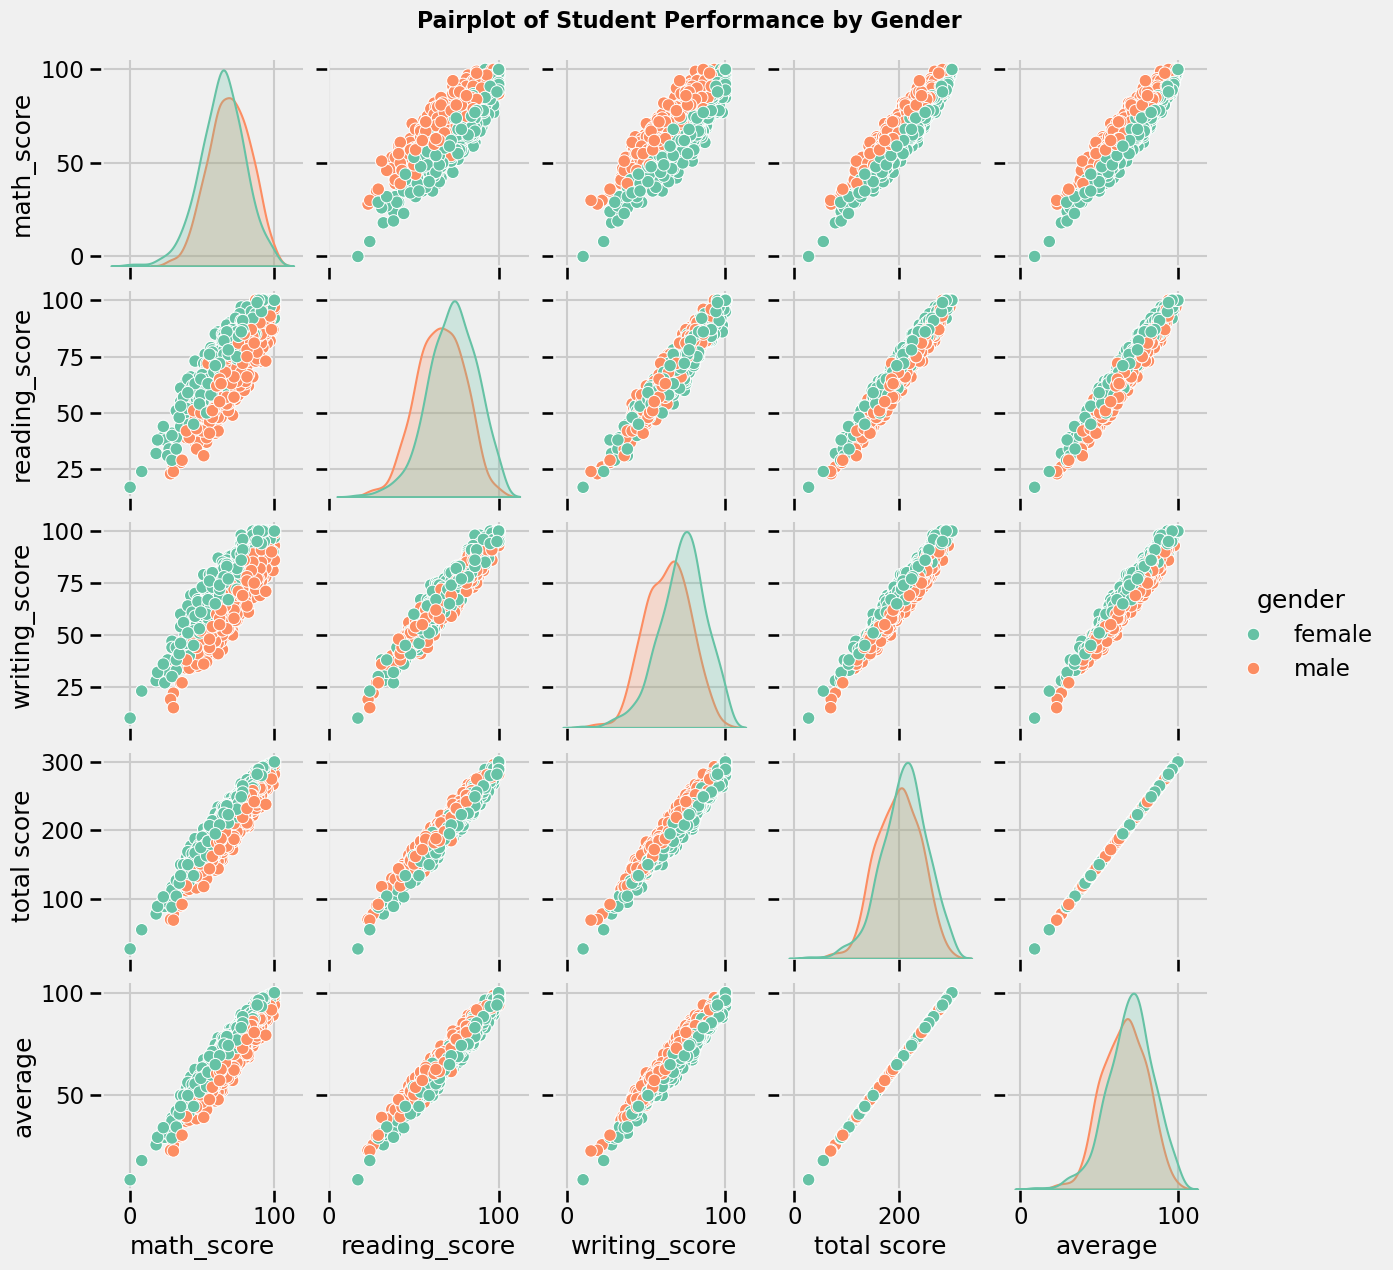

In [73]:
sns.pairplot(df, hue='gender', diag_kind='kde', palette='Set2')

plt.suptitle("Pairplot of Student Performance by Gender", y=1.02, fontsize=16, fontweight='bold')
plt.show()


Insights
* From the above plot it is clear that all the scores increase linearly with each other.


5. Conclusions

* Student's Performance is related with lunch, race, parental level education
* Females lead in pass percentage and also are top-scorers
* Student's Performance is not much related with test preparation course
* Finishing preparation course is benefitial.